In [1]:
!pip install librosa tensorflow numpy transformers soundfile tqdm


In [2]:
import tensorflow as tf
import numpy as np
import librosa, os
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from google.colab import drive
drive.mount('/content/drive')

# Load YAMNet from TensorFlow Hub
import tensorflow_hub as hub
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')

SAMPLE_RATE = 16000  # Required by YAMNet
GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop',
          'jazz', 'metal', 'pop', 'reggae', 'rock']


Mounted at /content/drive


In [3]:
def extract_yamnet_features(file_path):
    try:
        waveform, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)
        scores, embeddings, spectrogram = yamnet_model(tf.convert_to_tensor(waveform))
        return np.mean(embeddings.numpy(), axis=0)
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

In [4]:
import os
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tqdm import tqdm


DATASET_PATH = "/content/drive/MyDrive/ISBInternshipAIML/Data/genres_original"
features, labels = [], []

for genre in GENRES:
    genre_path = os.path.join(DATASET_PATH, genre)
    print(f"Processing {genre}...")

    file_list = os.listdir(genre_path)
    for file in tqdm(file_list):
        if file.endswith((".wav", ".au")):
            fpath = os.path.join(genre_path, file)

            try:
                feat = extract_yamnet_features(fpath)

                if feat is not None:
                    features.append(feat)
                    labels.append(genre)

            except Exception as e:
                print(f"\nError processing {fpath}: {e}. Skipping file.")

print("\nFeature extraction complete.")

# Convert lists to NumPy arrays
X = np.array(features)

# Encode labels
le = LabelEncoder()
y = to_categorical(le.fit_transform(labels))

print(f"Processed {len(X)} files successfully.")

Processing blues...


100%|██████████| 100/100 [00:57<00:00,  1.74it/s]


Processing classical...


100%|██████████| 100/100 [00:46<00:00,  2.16it/s]


Processing country...


...

Processing reggae...


100%|██████████| 100/100 [00:35<00:00,  2.79it/s]


Processing rock...


100%|██████████| 100/100 [00:36<00:00,  2.78it/s]


Feature extraction complete.
Processed 999 files successfully.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)


In [8]:
model = Sequential([
    Dense(512, activation='relu', input_shape=(1024,)),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(len(GENRES), activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)
model.save("yamnet_gtzan_final.h5")


Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.4332 - loss: 1.8199 - val_accuracy: 0.8240 - val_loss: 0.6764
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7536 - loss: 0.6673 - val_accuracy: 0.8080 - val_loss: 0.6066
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7953 - loss: 0.6170 - val_accuracy: 0.8240 - val_loss: 0.5381
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8380 - loss: 0.4569 - val_accuracy: 0.8280 - val_loss: 0.5420
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8436 - loss: 0.4664 - val_accuracy: 0.8280 - val_loss: 0.5485
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8614 - loss: 0.4094 - val_accuracy: 0.8200 - val_loss: 0.5342
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8768 - loss: 0.3564 - val_accuracy: 0.8200 - val_loss: 0.5866
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8760 - loss: 0.3622 - val_accuracy: 0.8240 - v

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8113 - loss: 0.6386
Test Accuracy: 81.60%


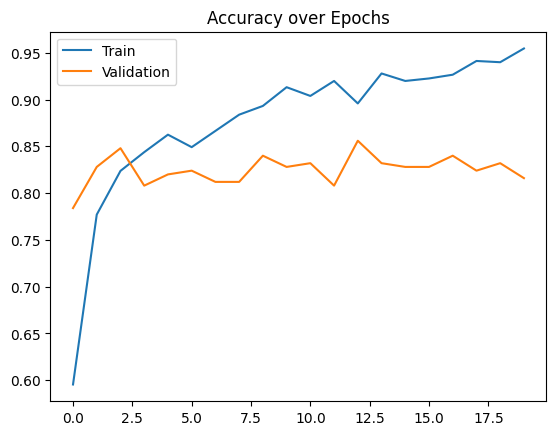

In [ ]:
import matplotlib.pyplot as plt

test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.2%}")

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy over Epochs")
plt.legend()
plt.show()


In [10]:
!pip install transformers accelerate torch soundfile


In [11]:
from transformers import AutoProcessor, MusicgenForConditionalGeneration
import torch
import soundfile as sf

processor = AutoProcessor.from_pretrained("facebook/musicgen-small")
musicgen = MusicgenForConditionalGeneration.from_pretrained("facebook/musicgen-small")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.36G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

In [12]:
prompt = ""
inputs = processor(text=prompt, padding=True, return_tensors="pt")

audio_values = musicgen.generate(**inputs, max_new_tokens=30*50)
sf.write("generated_music.wav", audio_values[0, 0].numpy(), 32000)
print("Music generated and saved as generated_music.wav")


Music generated and saved as generated_music.wav


In [13]:
!pip install transformers torch accelerate

from transformers import GPT2Tokenizer, GPT2LMHeadModel

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [14]:
def generate_lyrics(prompt, max_length=200):
    inputs = tokenizer.encode(prompt, return_tensors='pt')
    outputs = model.generate(
        inputs,
        max_length=max_length,
        temperature=0.8,
        top_p=0.9,
        do_sample=True,
        repetition_penalty=1.2
    )
    lyrics = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return lyrics


In [ ]:
prompt = "A bhangra beat with marriage song"

lyrics = generate_lyrics(f"Lyrics for {prompt}:")
print("Lyrics:\n", lyrics)

music_prompt = f"Instrumental background for: {prompt}"
inputs = processor(text=music_prompt, return_tensors="pt")
audio_values = musicgen.generate(**inputs, max_new_tokens=30 * 51)
sf.write("jazz_song.wav", audio_values[0, 0].numpy(), 32000)

print("Generated 30s music and lyrics for:", prompt)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Lyrics:
 Lyrics for A bhangra beat with marriage song:
- "Ya wudu, we are in a state of love." - The line is from the Chinese folk tune where one says that you're happy after all. (Translation by Ivo Farouq)
